# Day 08. Exercise 05
# Clustering

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [2]:
data = pd.read_csv('../data/regression.csv')

In [3]:
data.drop('pageviews', axis=1, inplace=True)
data

,uid,num_commits,AVG(diff)
0,user_1,62,-64.400000
1,user_10,20,-74.800000
2,user_14,61,-159.000000
3,user_17,51,-61.600000
4,user_18,5,-5.666667
5,user_19,118,-98.750000
6,user_21,65,-95.500000
7,user_25,79,-92.600000
8,user_28,60,-86.400000
9,user_3,18,-105.400000


## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [4]:
X = data[['num_commits', 'AVG(diff)']]

In [5]:
kmeans = KMeans(n_clusters=3, random_state=21)
kmeans.fit(X)

KMeans(n_clusters=3, random_state=21)

In [6]:
data['cluster'] = kmeans.labels_

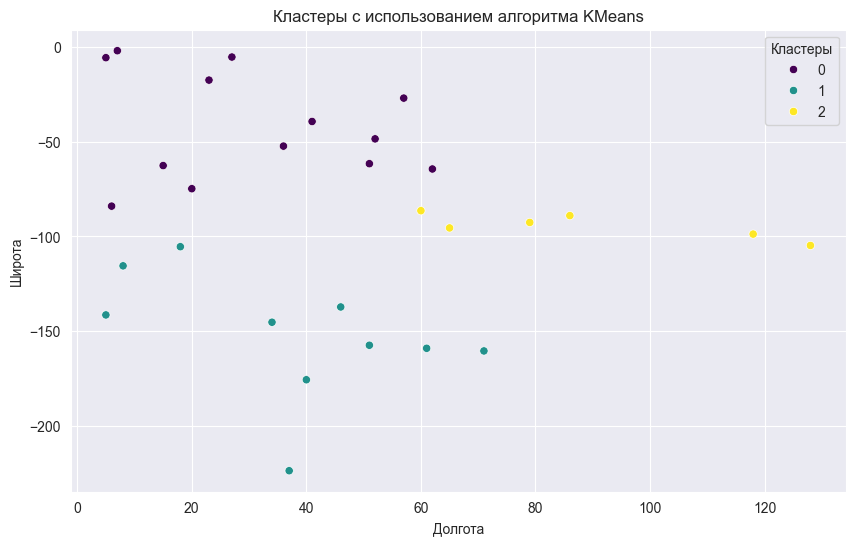

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='num_commits', y='AVG(diff)', hue='cluster', palette='viridis')
plt.title('Кластеры с использованием алгоритма KMeans')
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.legend(title='Кластеры')
plt.show()

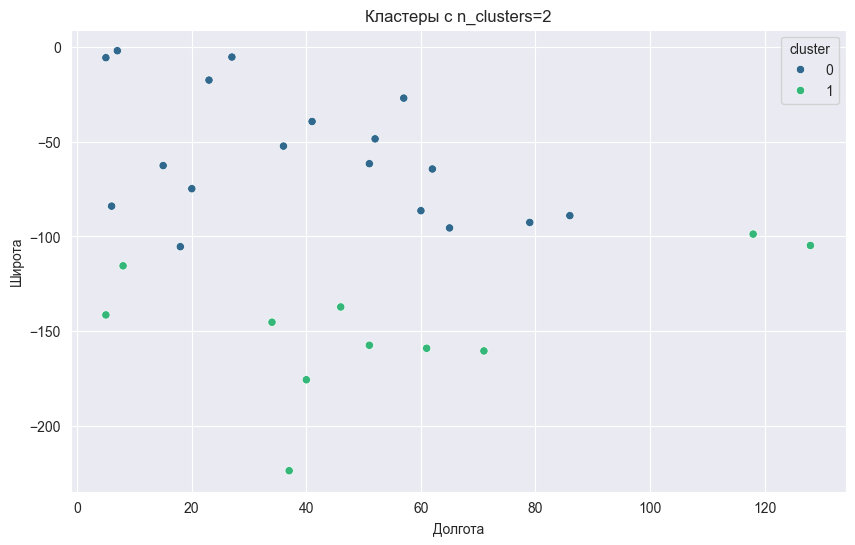

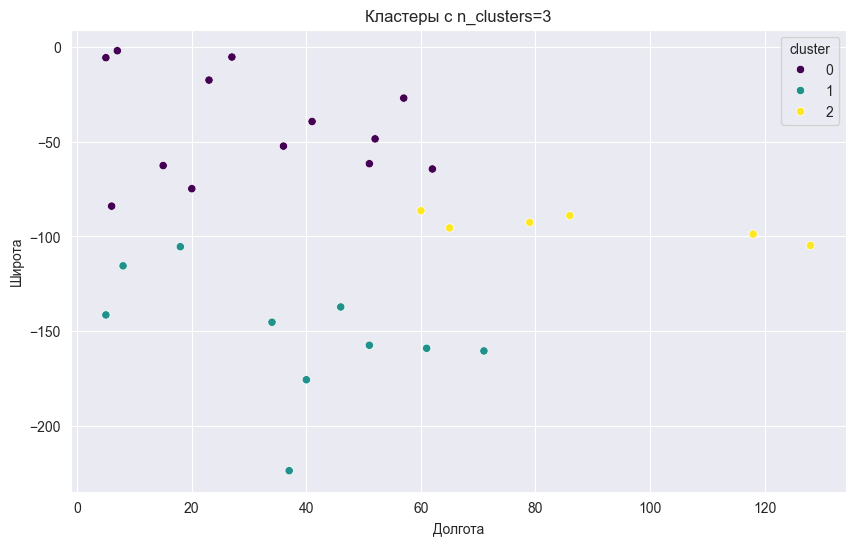

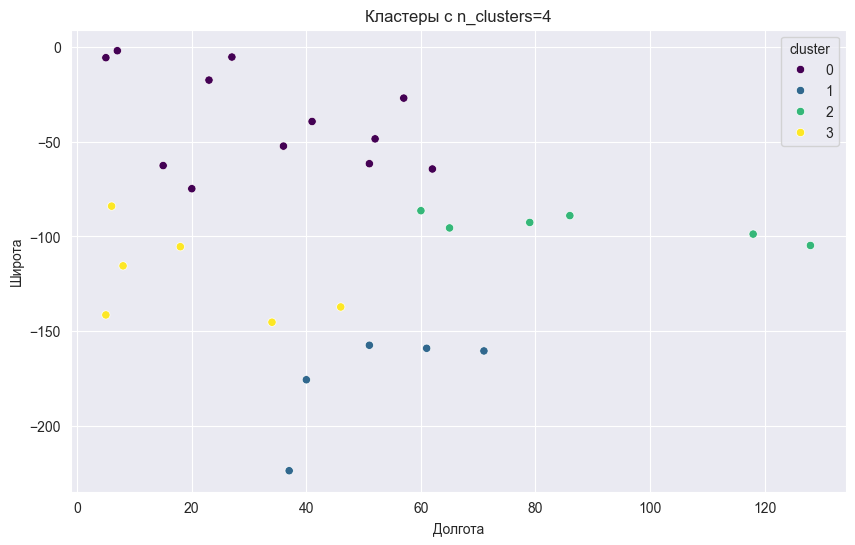

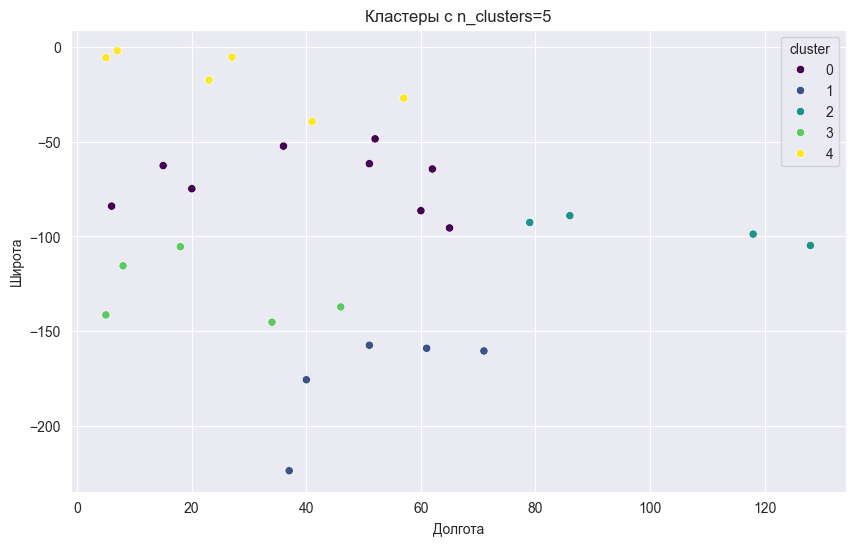

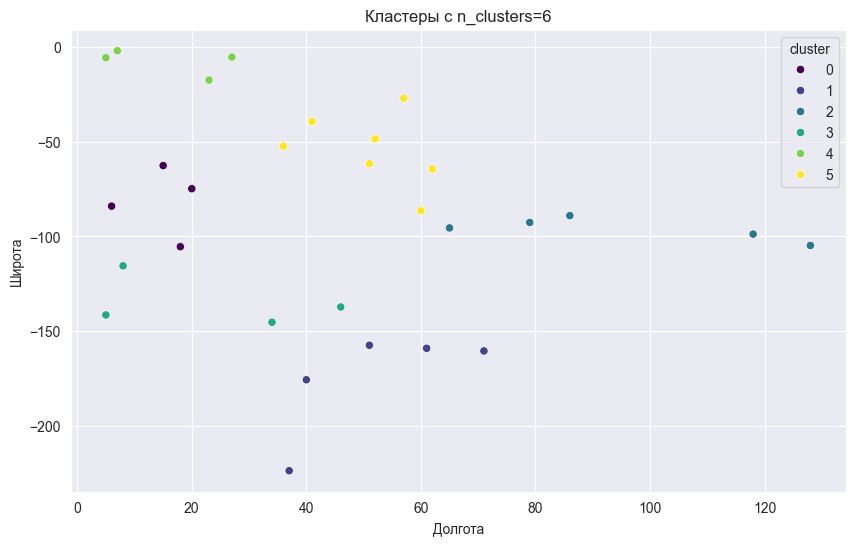

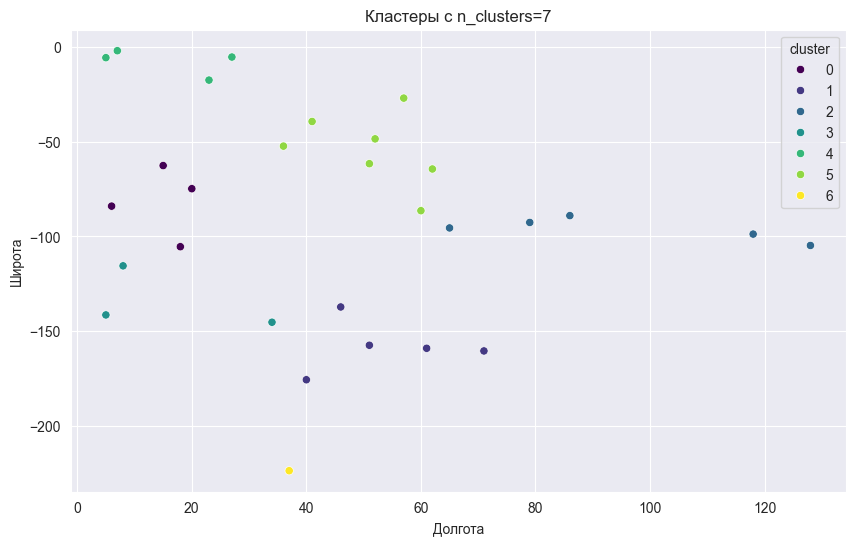

In [8]:
for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=21)
    kmeans.fit(X)
    data['cluster'] = kmeans.labels_

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=data, x='num_commits', y='AVG(diff)', hue='cluster', palette='viridis')
    plt.title(f'Кластеры с n_clusters={k}')
    plt.xlabel('Долгота')
    plt.ylabel('Широта')
    plt.show()


In [9]:
score = silhouette_score(X, kmeans.labels_)
print(f'Silhouette Score для n_clusters = 3: {score}')

Silhouette Score для n_clusters = 3: 0.3963747661984397


## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [10]:
dbscan = DBSCAN(eps=20, min_samples=2)
labels = dbscan.fit_predict(X)

In [11]:
data['cluster'] = labels

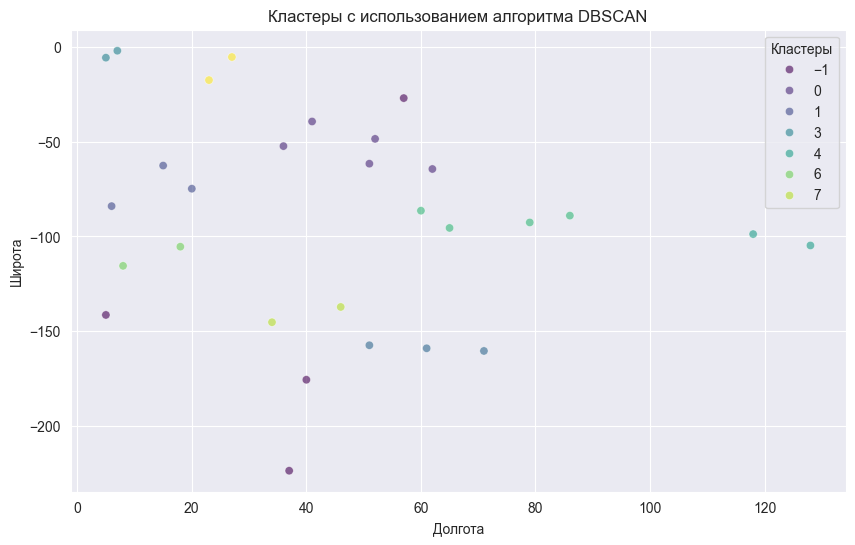

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='num_commits', y='AVG(diff)', hue='cluster', palette='viridis', alpha=0.6)
plt.title('Кластеры с использованием алгоритма DBSCAN')
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.legend(title='Кластеры')
plt.show()

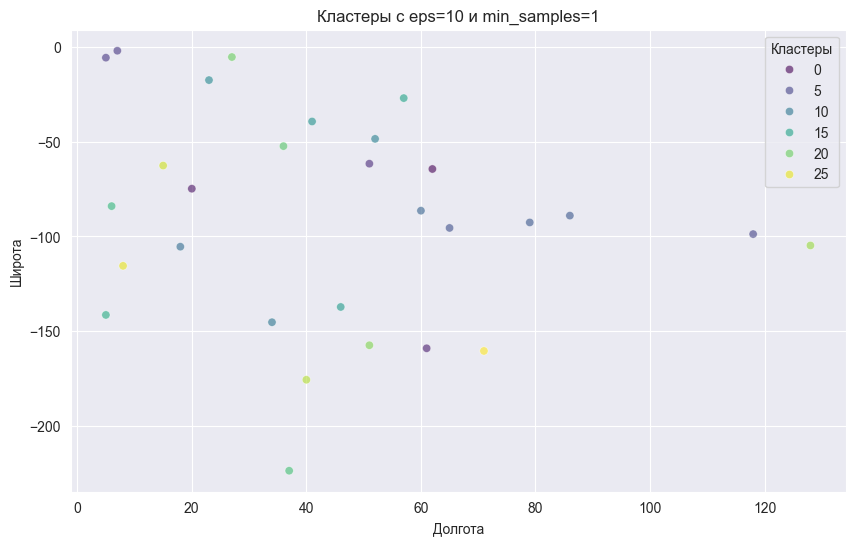

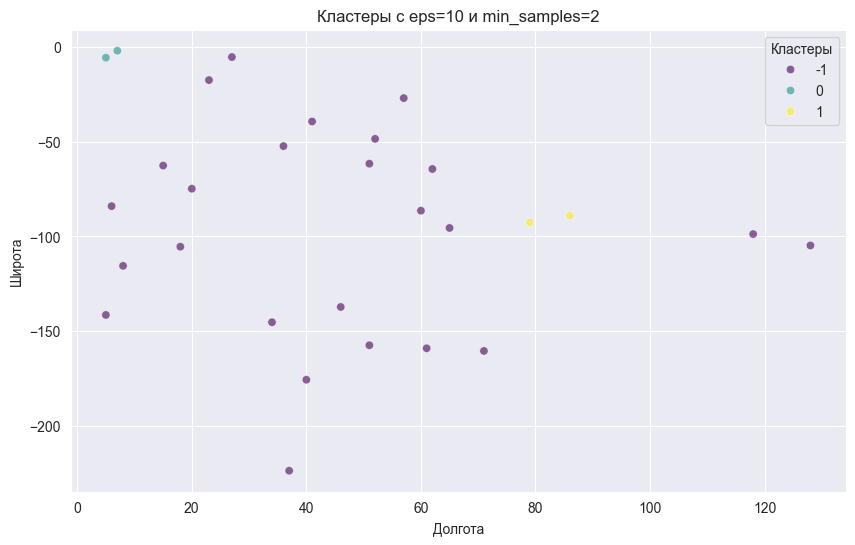

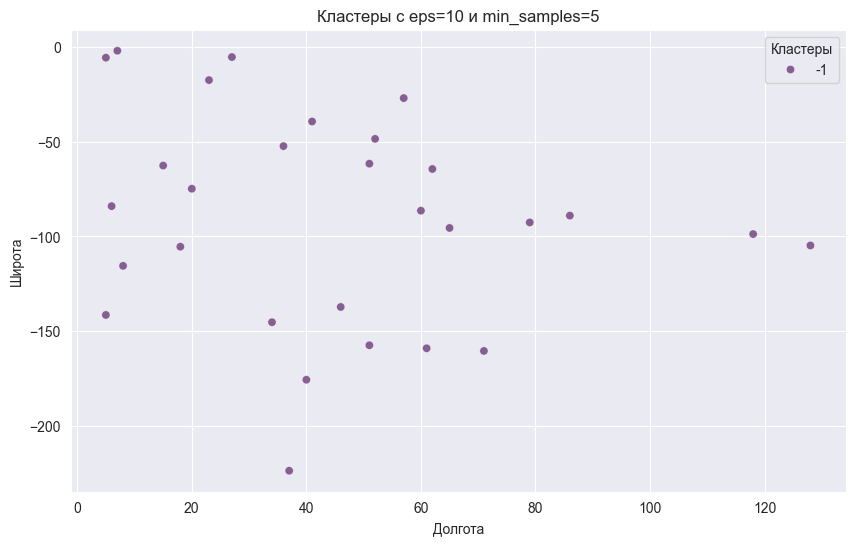

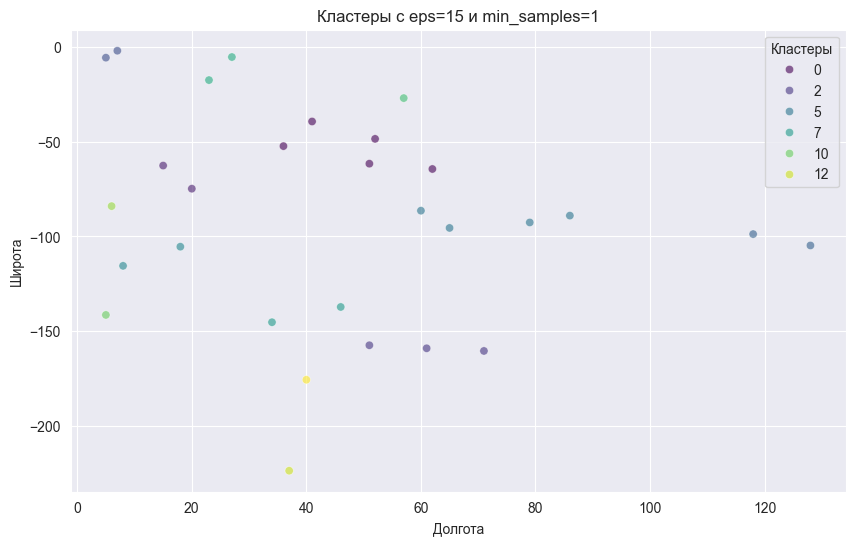

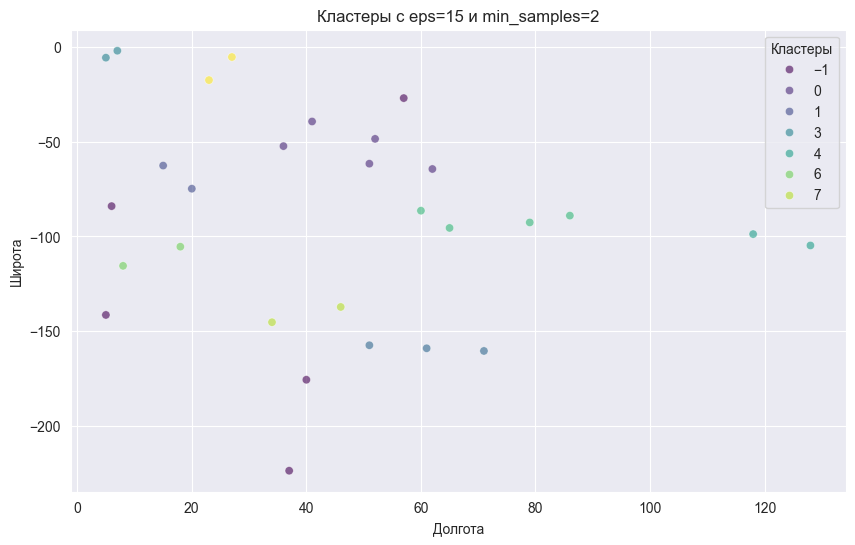

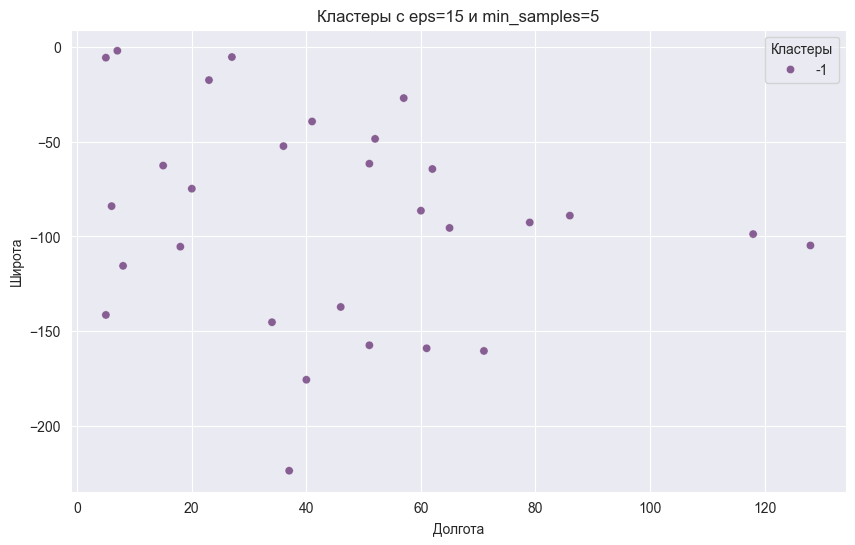

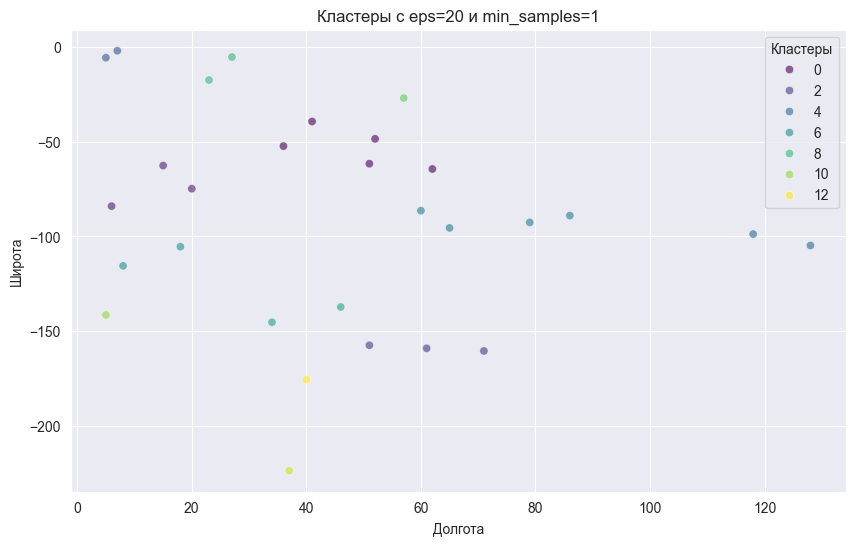

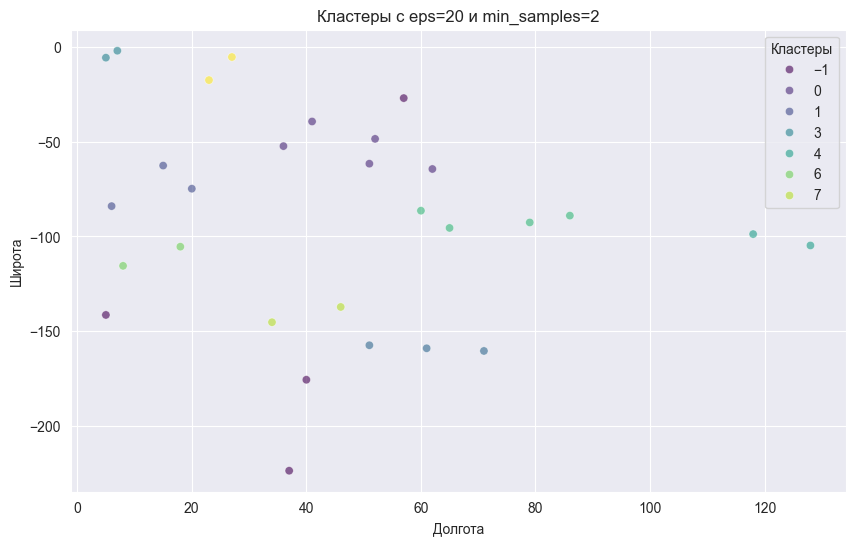

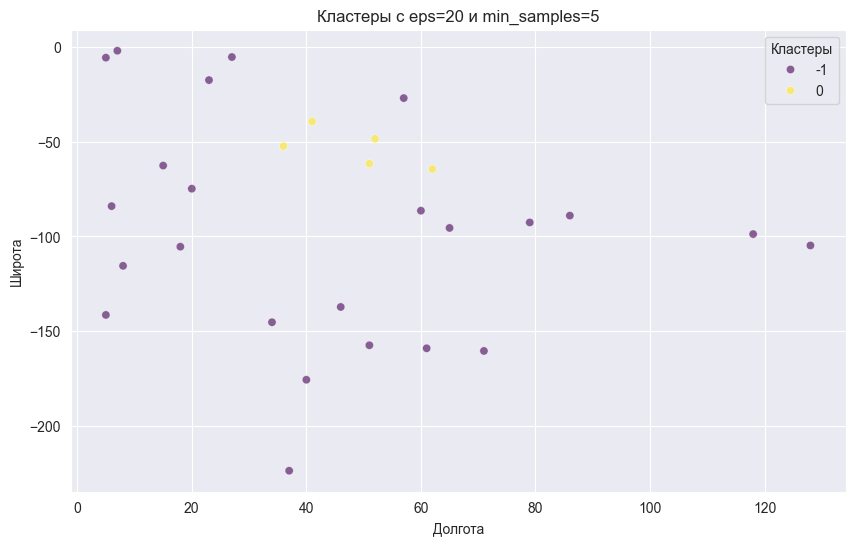

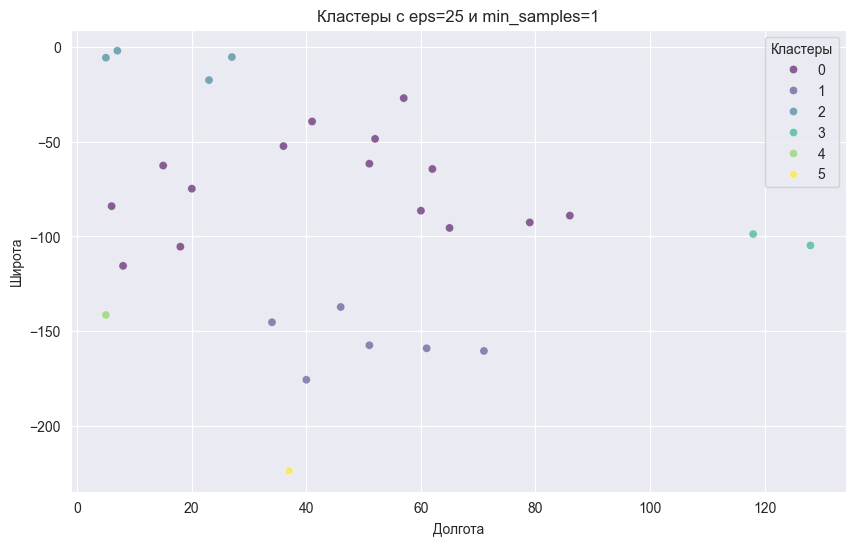

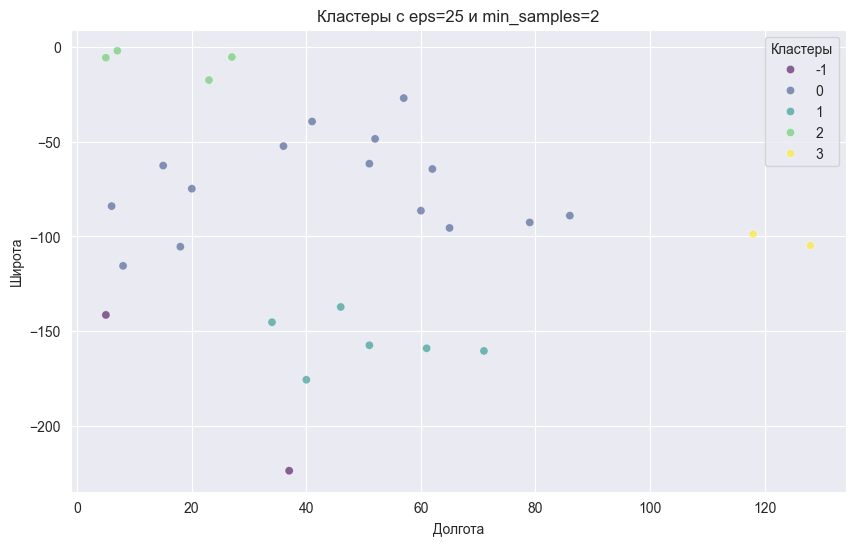

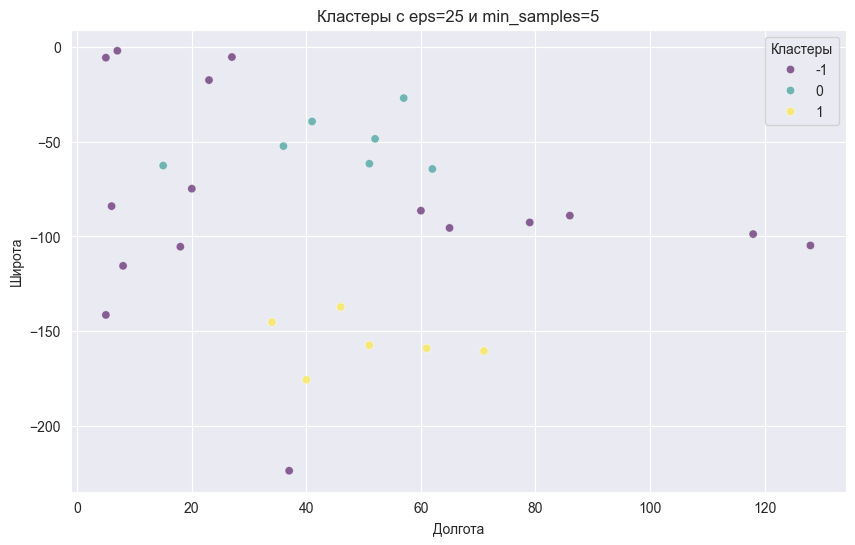

In [13]:
for eps in [10, 15, 20, 25]:
    for min_samples in [1, 2, 5]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)
        
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=data, x='num_commits', y='AVG(diff)', hue=labels, palette='viridis', alpha=0.6)
        plt.title(f'Кластеры с eps={eps} и min_samples={min_samples}')
        plt.xlabel('Долгота')
        plt.ylabel('Широта')
        plt.legend(title='Кластеры')
        plt.show()

In [14]:
if len(set(labels)) > 1:
    score = silhouette_score(X, labels)
    print(f'Silhouette Score для eps={20} и min_samples={2}: {score}')
else:
    print('Недостаточно кластеров для вычисления silhouette score.')

Silhouette Score для eps=20 и min_samples=2: 0.12320173333939347


## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

In [15]:
model = AgglomerativeClustering(n_clusters=5)
labels = model.fit_predict(X)

In [16]:
data['cluster'] = labels

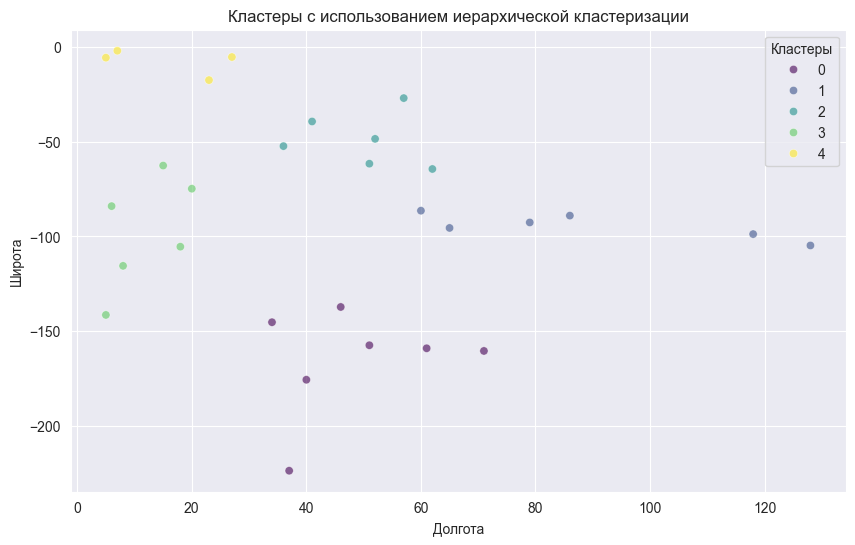

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='num_commits', y='AVG(diff)', hue='cluster', palette='viridis', alpha=0.6)
plt.title('Кластеры с использованием иерархической кластеризации')
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.legend(title='Кластеры')
plt.show()

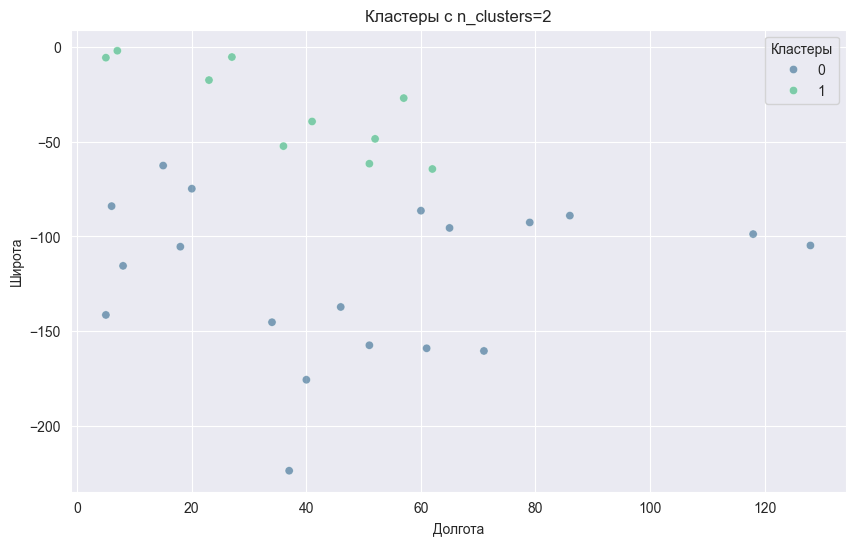

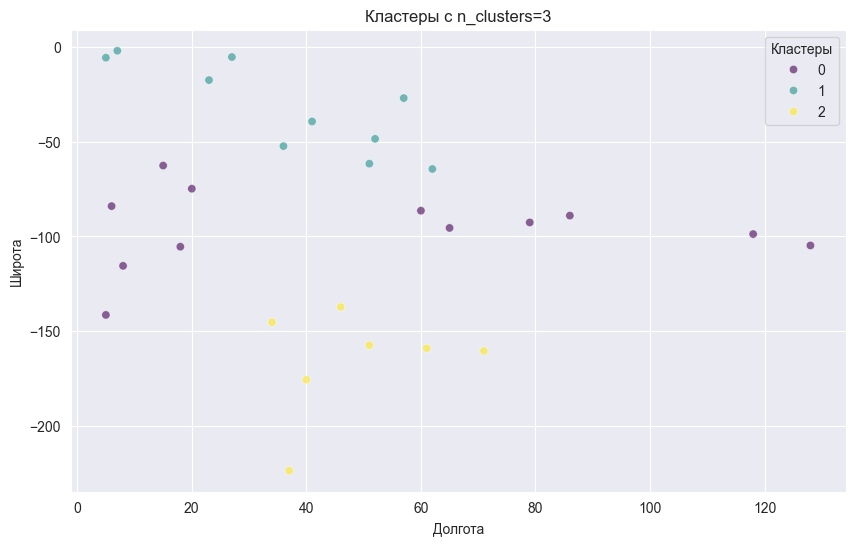

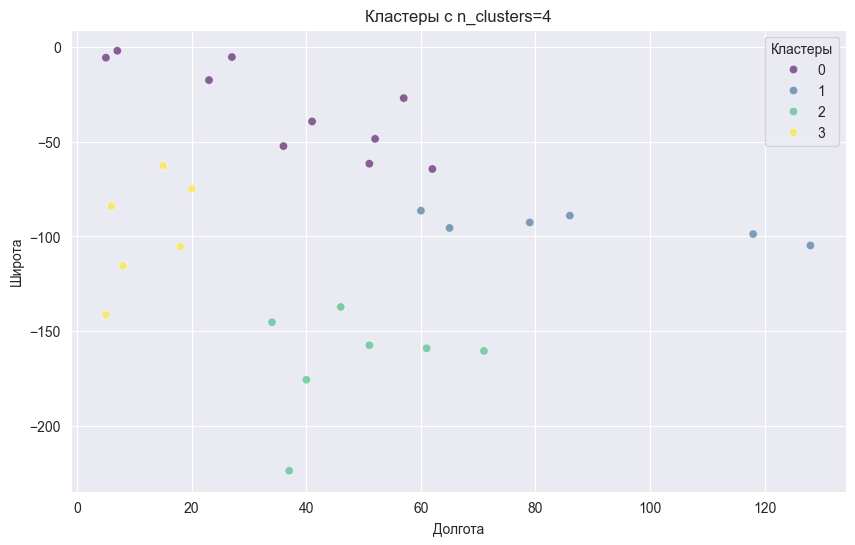

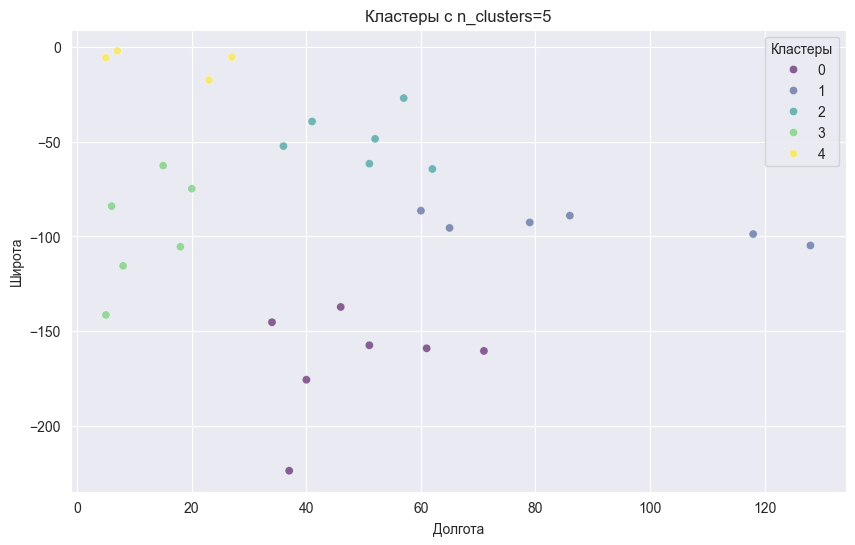

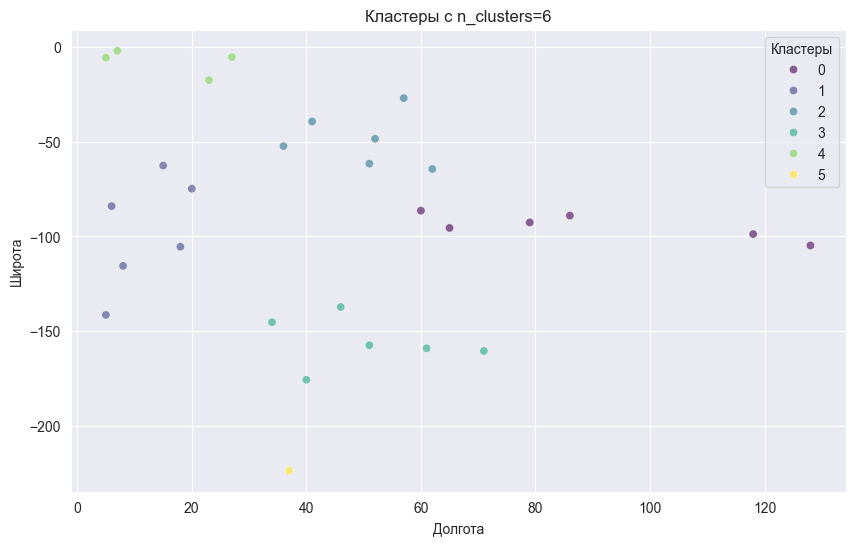

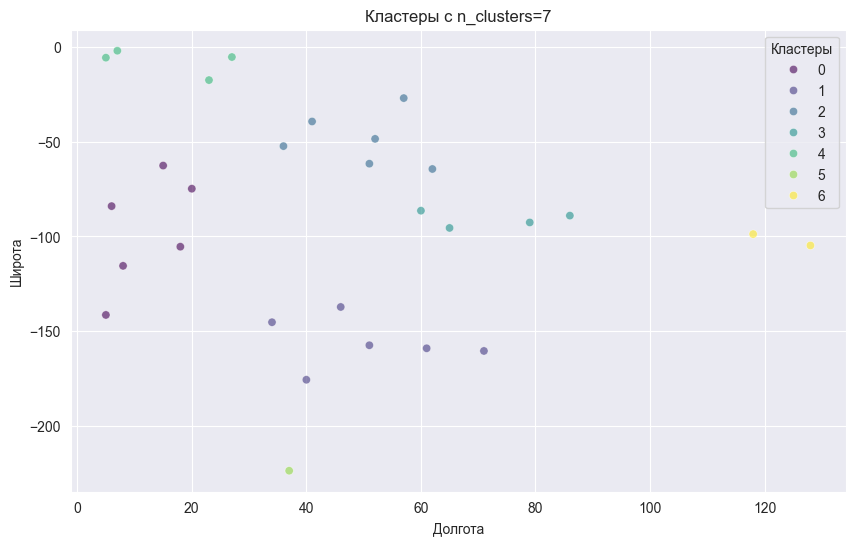

In [18]:
for n in range(2, 8):
    model = AgglomerativeClustering(n_clusters=n)
    labels = model.fit_predict(X)
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=data, x='num_commits', y='AVG(diff)', hue=labels, palette='viridis', alpha=0.6)
    plt.title(f'Кластеры с n_clusters={n}')
    plt.xlabel('Долгота')
    plt.ylabel('Широта')
    plt.legend(title='Кластеры')
    plt.show()


In [19]:
score = silhouette_score(X, labels)
print(f'Silhouette Score для n_clusters=5: {score}')

Silhouette Score для n_clusters=5: 0.4865808853184314


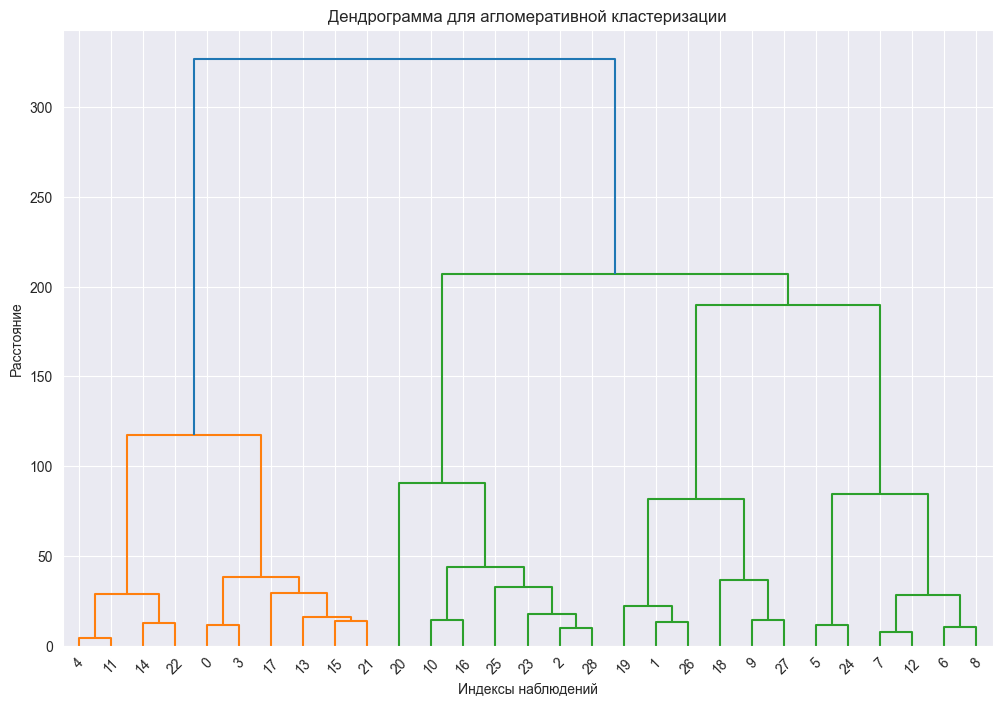

In [20]:
plt.figure(figsize=(12, 8))
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Дендрограмма для агломеративной кластеризации')
plt.xlabel('Индексы наблюдений')
plt.ylabel('Расстояние')
plt.show()

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.

In [21]:
def optimize_clustering(model_class, param_name, param_range, X):
    silhouette_scores = []
    best_score = -1
    best_param_value = None
    best_labels = None

    for param_value in param_range:
        model = model_class(**{param_name: param_value})
        labels = model.fit_predict(X)

        if len(set(labels)) > 1:
            score = silhouette_score(X, labels)
            silhouette_scores.append(score)

            if score > best_score:
                best_score = score
                best_param_value = param_value
                best_labels = labels
        else:
            silhouette_scores.append(-1)

    fig, axs = plt.subplots(1, 2, figsize=(15, 6))

    axs[0].plot(param_range, silhouette_scores, marker='o')
    axs[0].set_title('Изменение silhouette_score в зависимости от параметра')
    axs[0].set_xlabel(param_name)
    axs[0].set_ylabel('Silhouette Score')
    axs[0].axvline(best_param_value, color='r', linestyle='--', label='Лучшее значение')
    axs[0].legend()

    best_model = model_class(**{param_name: best_param_value})
    best_labels = best_model.fit_predict(X)

    scatter = axs[1].scatter(X.iloc[:, 0], X.iloc[:, 1], c=best_labels, cmap='viridis', alpha=0.6)
    axs[1].set_title(f'Визуализация данных с {param_name}={best_param_value}')
    axs[1].set_xlabel('num_commits')
    axs[1].set_ylabel('AVG(diff)')

    handles, _ = scatter.legend_elements()
    labels = np.unique(best_labels) 
    axs[1].legend(handles, labels, title="Кластеры")

    plt.tight_layout()
    plt.show()

    return best_param_value

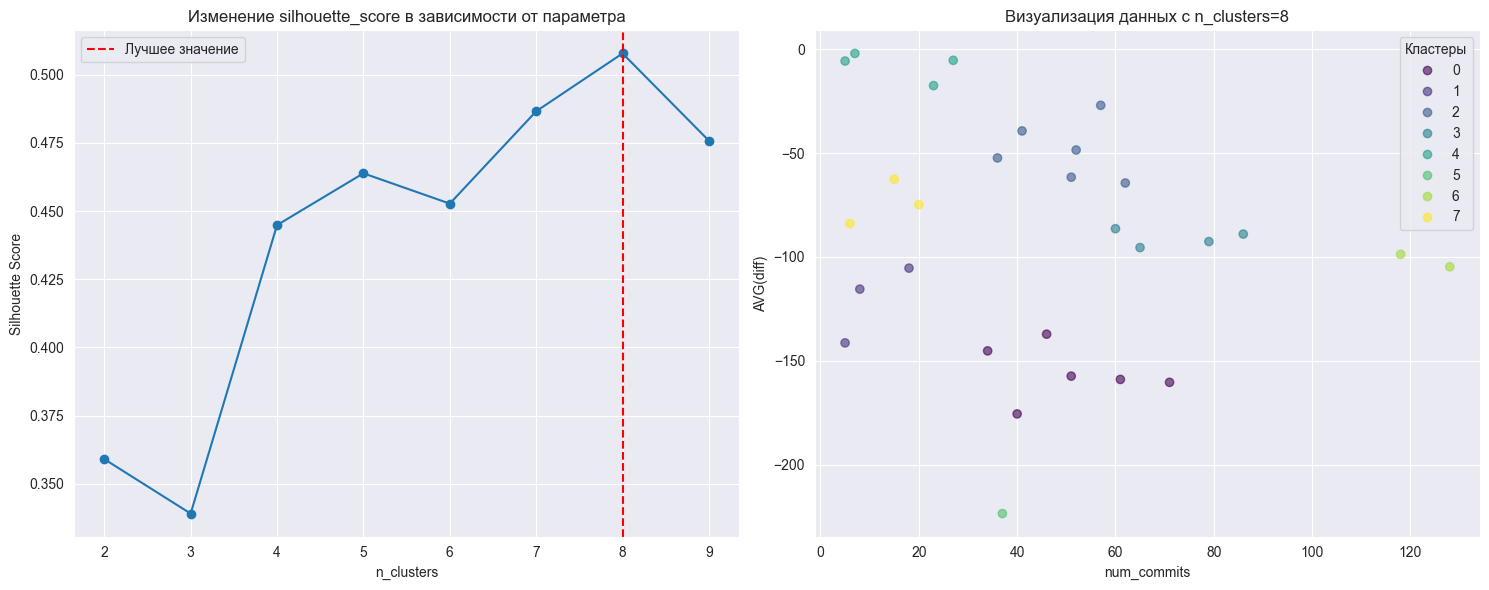

8

In [22]:
optimize_clustering(AgglomerativeClustering, 'n_clusters', range(2, 10), data[['num_commits', 'AVG(diff)']])